**CREDIT CARD FRAUD DETECTION**

The dataset contains transactions made by credit cards in September 2013 by European cardholders. This presents transactions that occurred in two days where there were 284,807 transactions.

**Setup & Load Data**

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import time

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Exploratory Check**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

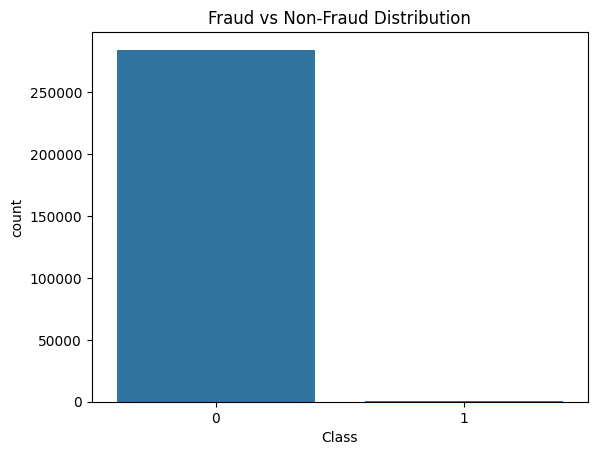

In [ ]:
df.info()

# Class imbalance check
df['Class'].value_counts()

# Plot class distribution
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


**Train - Test**

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

**Decision Tree Model**

In [ ]:
start = time.time()

from sklearn.metrics import roc_auc_score

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt.fit(X_train, y_train)

dt_time = time.time() - start

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

dt_probs = dt.predict_proba(X_test)[:, 1]
dt_auc = roc_auc_score(y_test, dt_probs)

dt_acc, dt_f1, dt_time, dt_auc

(0.9994382219725431,
 0.8222222222222222,
 7.860153913497925,
 np.float64(0.8816368232350998))

**Random Forest Model**

In [ ]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Data loading and splitting (moved from previous cells to make this cell self-contained)
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_time = time.time() - start

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# Calculate ROC-AUC for Random Forest
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

rf_acc, rf_f1, rf_time, rf_auc

(0.9995084442259752,
 0.8409090909090909,
 111.60554599761963,
 np.float64(0.9682148837975675))

**Gradient Boosting Model**

In [ ]:
start = time.time()

gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbm.fit(X_train, y_train)

gbm_time = time.time() - start

gbm_pred = gbm.predict(X_test)

gbm_acc = accuracy_score(y_test, gbm_pred)
gbm_f1 = f1_score(y_test, gbm_pred)

# Calculate ROC-AUC for Gradient Boosting
gbm_probs = gbm.predict_proba(X_test)[:, 1]
gbm_auc = roc_auc_score(y_test, gbm_probs)

gbm_acc, gbm_f1, gbm_time, gbm_auc

(0.9984434067155882,
 0.26519337016574585,
 401.4655616283417,
 np.float64(0.34459051495366644))

**Logistic Regression**

In [ ]:
import time

start = time.time()

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score # Import roc_auc_score

logreg = LogisticRegression(
    penalty='l2',
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logreg.fit(X_train, y_train)

logreg_time = time.time() - start

logreg_pred = logreg.predict(X_test)

logreg_acc = accuracy_score(y_test, logreg_pred)
logreg_f1  = f1_score(y_test, logreg_pred)

# Calculate ROC-AUC for Logistic Regression
logreg_probs = logreg.predict_proba(X_test)[:, 1]
log_auc = roc_auc_score(y_test, logreg_probs)

logreg_acc, logreg_f1, logreg_time, log_auc

(0.9749891740692626,
 0.10772442588726514,
 51.00576901435852,
 np.float64(0.9666088123412702))

**Light GBM**

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [ ]:
start = time.time()

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

lgbm_time = time.time() - start

lgbm_pred = lgbm.predict(X_test)

lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_f1 = f1_score(y_test, lgbm_pred)


[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


**ROC Functions**

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

**Predicted Probability**

In [ ]:
lgbm_probs = lgbm.predict_proba(X_test)[:, 1]

**ROC Curve Calculation Light GBM**

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, lgbm_probs)

**AUC Score Light GBM**

In [ ]:
lgbm_auc = roc_auc_score(y_test, lgbm_probs)
lgbm_auc

np.float64(0.9752135276140199)

**ROC Curve Plot Light GBM**

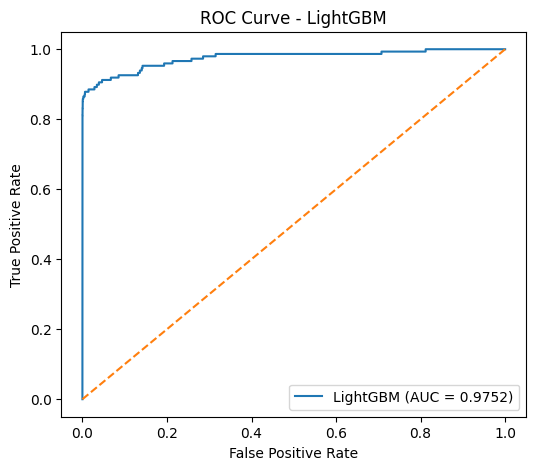

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LightGBM (AUC = {lgbm_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--')  # random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.show()

**CAT GBM**

In [ ]:
!pip install catboost

from catboost import CatBoostClassifier
import time
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


In [ ]:
start = time.time()

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, 100],
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_time = time.time() - start


**Prediction and Metrics**

In [ ]:
cat_pred = cat_model.predict(X_test)

cat_acc = accuracy_score(y_test, cat_pred)
cat_f1 = f1_score(y_test, cat_pred)

cat_acc, cat_f1, cat_time


(0.9993562960102056, 0.8135593220338984, 17.733084678649902)

**Confusion Matrix**

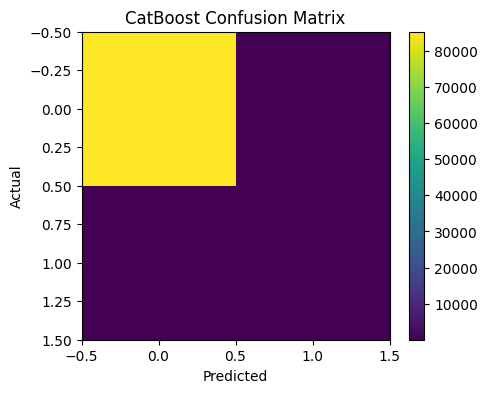

In [ ]:
cm = confusion_matrix(y_test, cat_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("CatBoost Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**ROC Curve and AUC**

In [ ]:
cat_probs = cat_model.predict_proba(X_test)[:, 1]

In [ ]:
fpr, tpr, _ = roc_curve(y_test, cat_probs)
cat_auc = roc_auc_score(y_test, cat_probs)
cat_auc


np.float64(0.9643175592498531)

**ROC Plot**

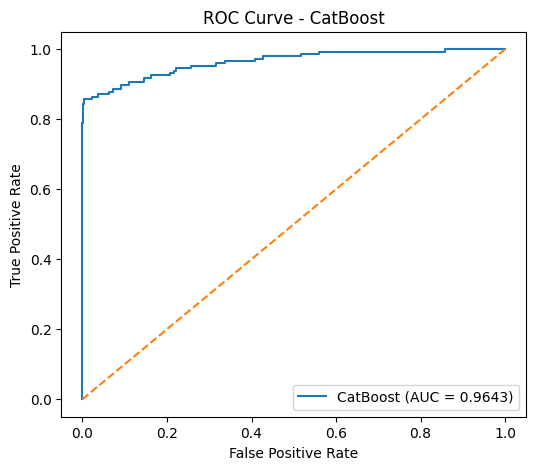

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"CatBoost (AUC = {cat_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.show()

**Model Comparison Table**

In [ ]:
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "LightGBM",
        "CatBoost"
    ],
    "Accuracy": [
        logreg_acc,
        dt_acc,
        rf_acc,
        gbm_acc,
        lgbm_acc,
        cat_acc
    ],
    "F1 Score": [
        logreg_f1,
        dt_f1,
        rf_f1,
        gbm_f1,
        lgbm_f1,
        cat_f1
    ],
    "ROC-AUC": [
        log_auc,
        dt_auc,
        rf_auc,
        gbm_auc,
        lgbm_auc,
        cat_auc
    ],
    "Run Time (seconds)": [
        logreg_time,
        dt_time,
        rf_time,
        gbm_time,
        lgbm_time,
        cat_time
    ]
})

comparison_table

,Model,Accuracy,F1 Score,ROC-AUC,Run Time (seconds)
0,Logistic Regression,0.974989,0.107724,0.966609,51.005769
1,Decision Tree,0.999438,0.822222,0.881637,7.860154
2,Random Forest,0.999508,0.840909,0.968215,111.605546
3,Gradient Boosting,0.998443,0.265193,0.344591,401.465562
4,LightGBM,0.999508,0.847826,0.975214,8.113944
5,CatBoost,0.999356,0.813559,0.964318,17.733085


**Feature Importance**

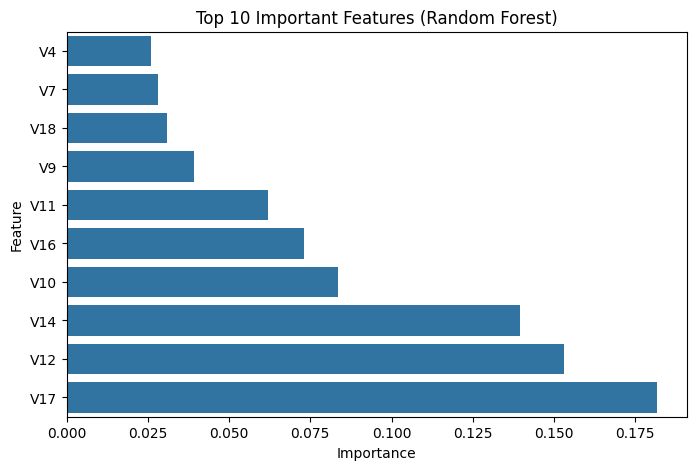

In [ ]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 10 Important Features (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


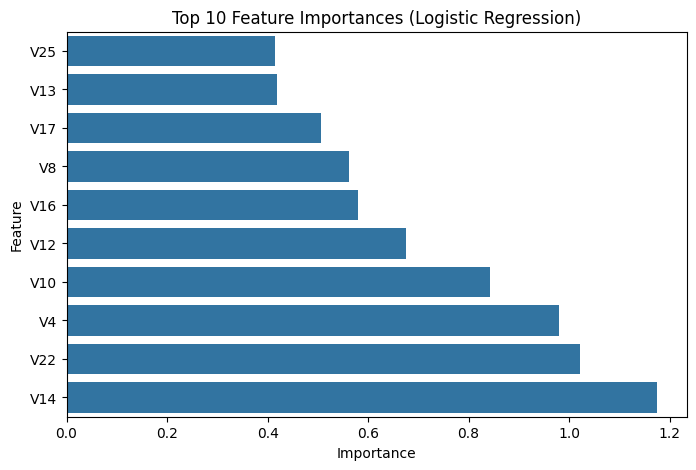

In [ ]:
log_feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(logreg.coef_[0])
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=log_feat_df)
plt.title("Top 10 Feature Importances (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

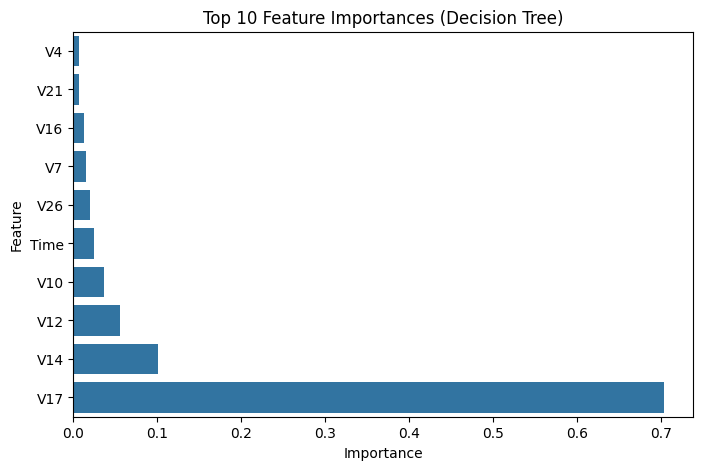

In [ ]:
dt_feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=dt_feat_df)
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.gca().invert_yaxis()
plt.show()



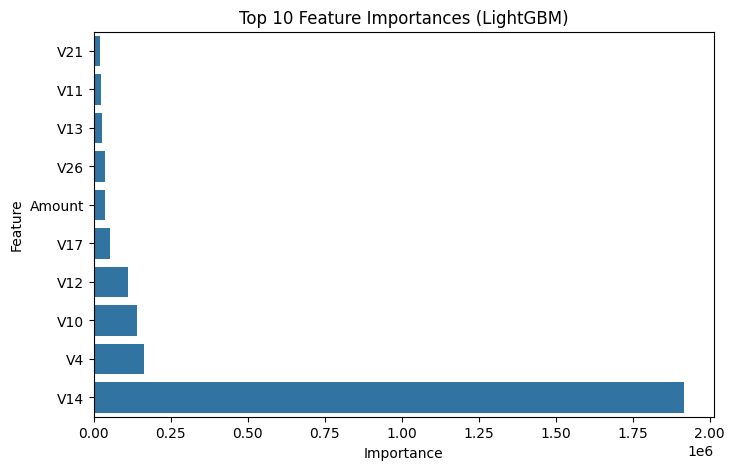

In [ ]:
lgb_feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm.booster_.feature_importance(importance_type='gain')
}).sort_values(by="Importance", ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=lgb_feat_df)
plt.title("Top 10 Feature Importances (LightGBM)")
plt.gca().invert_yaxis()
plt.show()


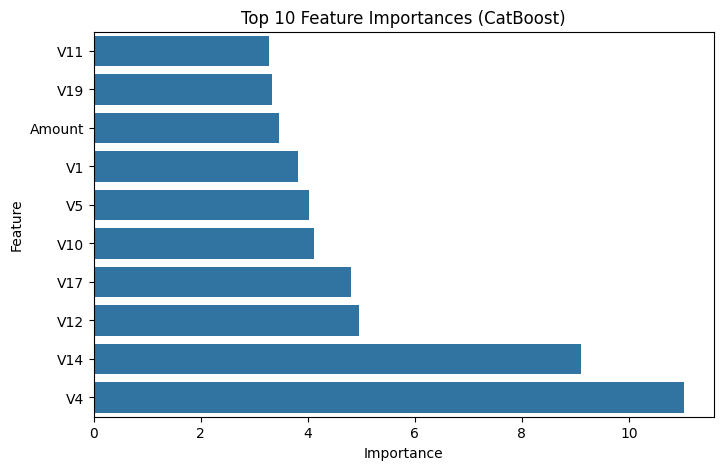

In [ ]:
cat_feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=cat_feat_df)
plt.title("Top 10 Feature Importances (CatBoost)")
plt.gca().invert_yaxis()
plt.show()


**Hyperparameter Tuning**

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

**SHAP for Random Forest**

In [ ]:
!pip install shap

import shap
import matplotlib.pyplot as plt

explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)



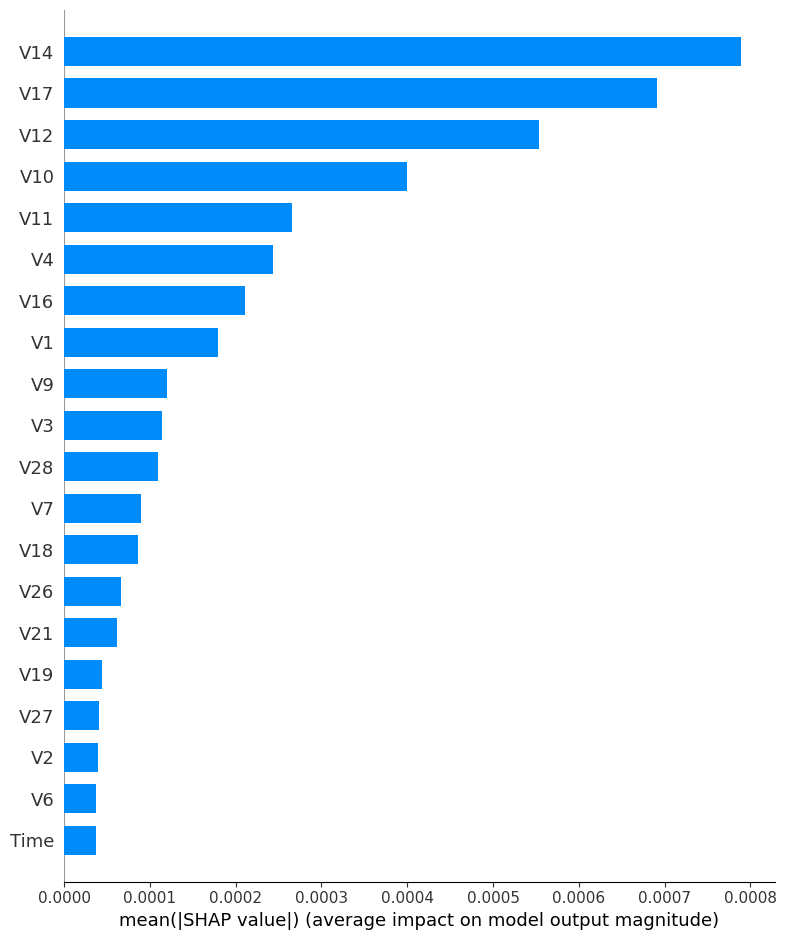

In [ ]:
shap.summary_plot(
    shap_values_rf[:, :, 1], # Correctly extract SHAP values for class 1
    X_test,
    plot_type="bar"
)

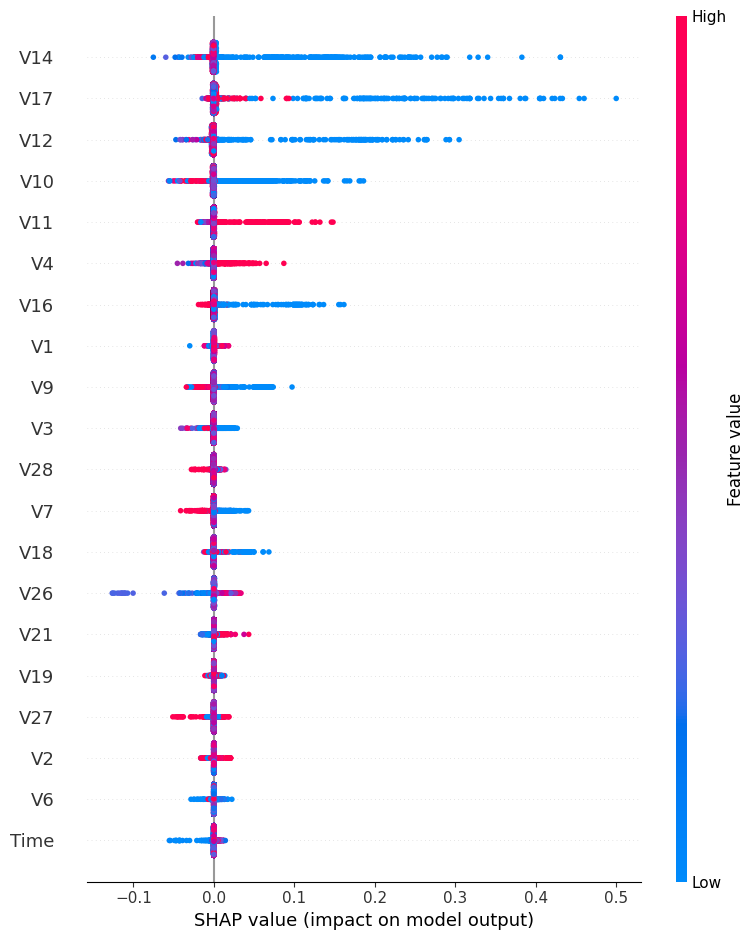

In [ ]:
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_test
)